# WSTĘP

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

from xgboost import XGBClassifier, plot_importance

from visualization import visualize_categorical_feature_distributions, visualize_numeric_feature_distributions, visualize_binary_feature_distributions, visualize_target_distribution

### ŁADOWANIE DANYCH


In [3]:
data = pd.read_csv('banking_transactions.csv')
if 'transaction_id' in data.columns:
    data = data.drop('transaction_id', axis=1) # transaction_id to unikalny identyfikator i nie wnosi wartości do analizy
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = data.select_dtypes(include=['object', 'str']).columns.tolist()
binary_columns = [col for col in numeric_columns if data[col].nunique() == 2]
numeric_columns = [col for col in numeric_columns if col not in binary_columns]
features = {
    "numeric": numeric_columns,
    "categorical": categorical_columns,
    "binary": binary_columns
}
data_encoded = pd.get_dummies(data, columns=categorical_columns, dtype=int)
data_encoded['fraud_flag'] = data_encoded['fraud_flag'].astype(int)

### ANALIZA

== EXPLORATORY DATA ANALYSIS ==
   transaction_amount  login_attempts  device_risk_score  transfer_frequency  \
0            17829.01               4               12.0                  13   
1            16401.83               1               34.3                  17   
2             9678.29               8               67.8                  39   
3            19013.38               5               17.8                  42   
4            13834.95               3               88.9                  63   

   anomaly_score  account_age_days  transaction_time_hour  \
0           0.37              2354                     22   
1           0.26              3181                     17   
2           0.15              1390                      3   
3           0.55              3716                     16   
4           0.24              4694                     16   

   failed_transactions_last_30d  avg_monthly_balance  daily_transaction_count  \
0                            25        

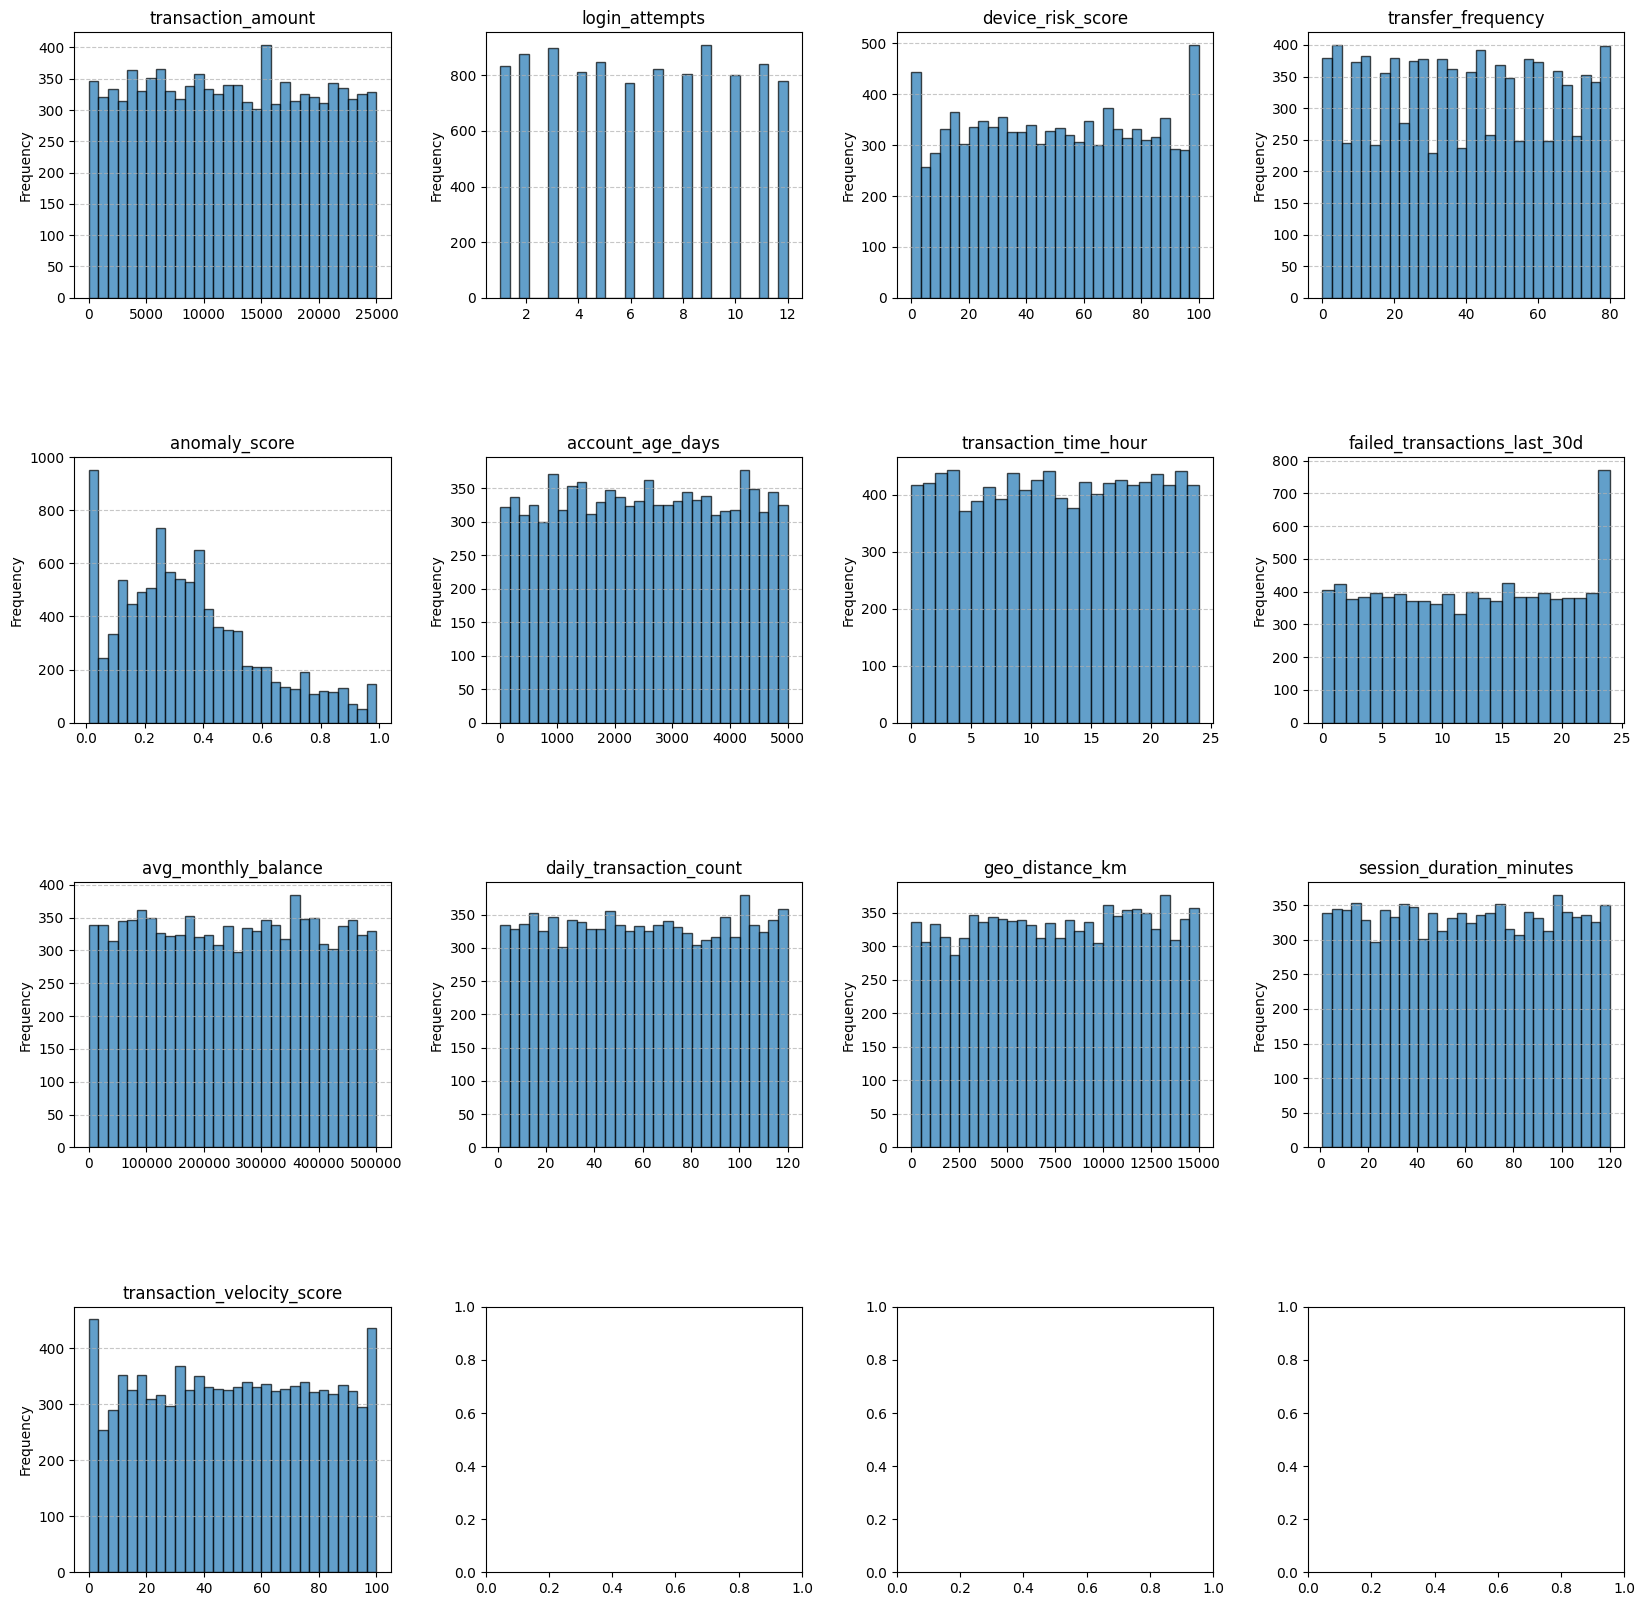


- Categorical Feature Distributions -
payment_channel: {'Mobile App': 4804, 'Web Banking': 3247, 'POS Terminal': 1172, 'ATM': 777}
authentication_type: {'OTP': 4214, 'Two-Factor Authentication': 2384, 'Password Only': 1817, 'Biometric': 1585}


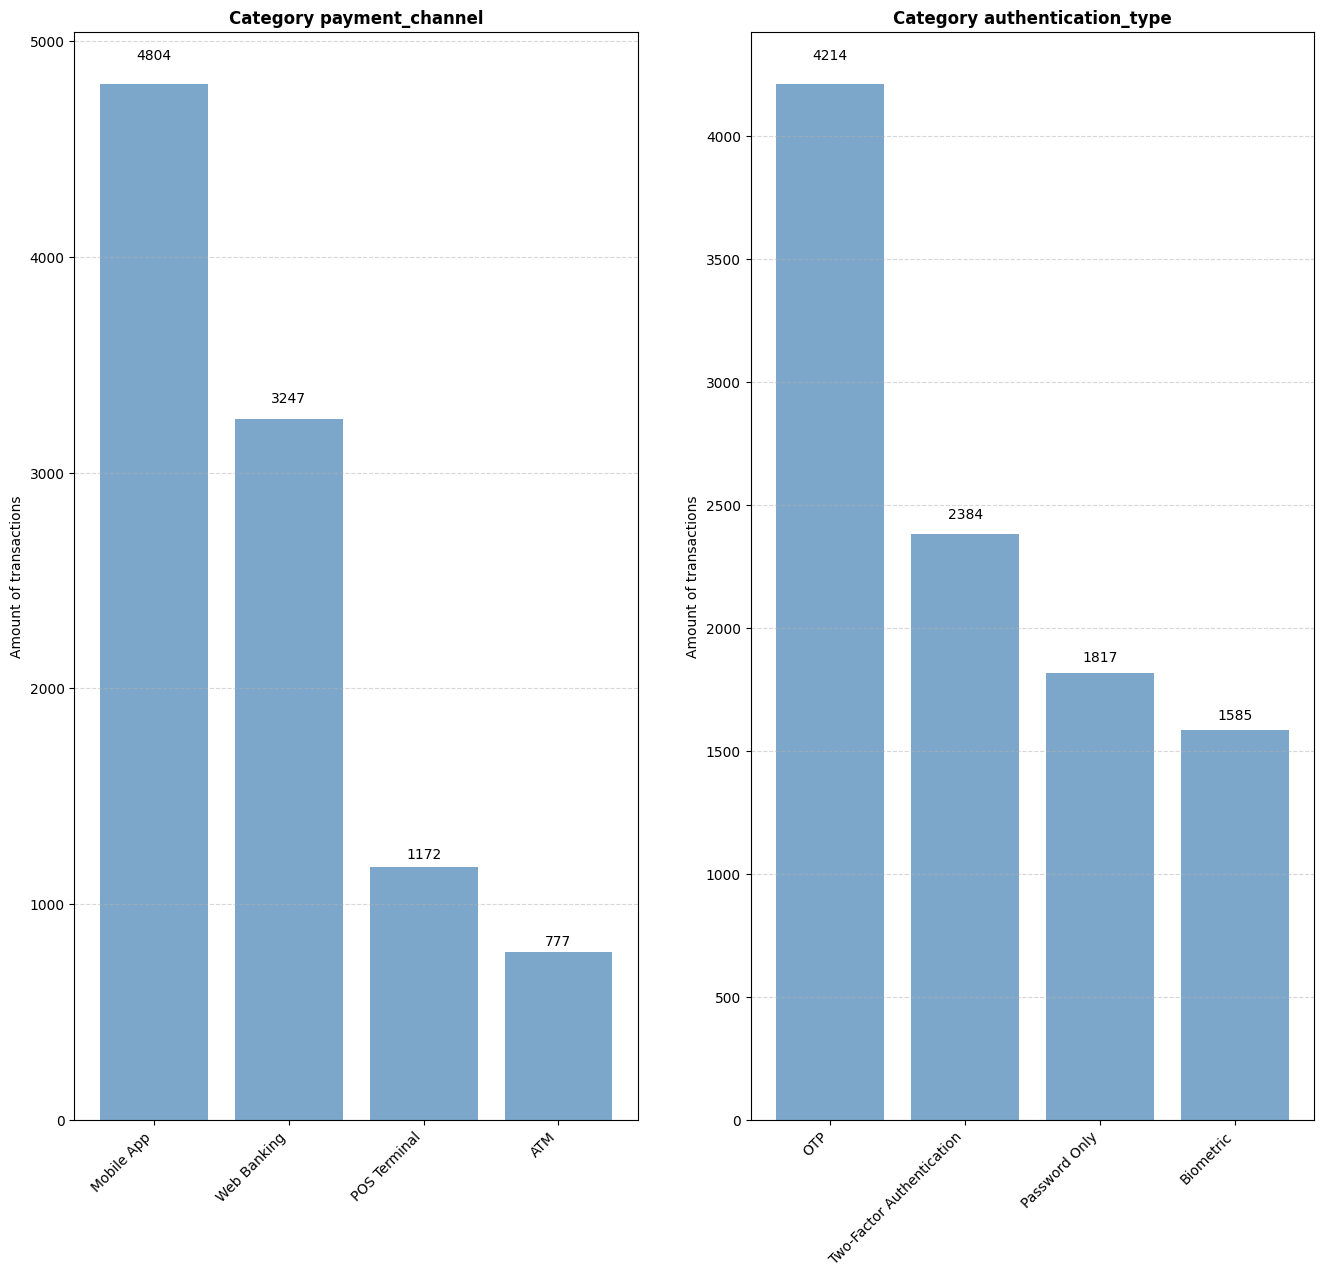


- Binary Feature Distributions -
card_present_flag: {0: 5072, 1: 4928}
international_transaction_flag: {0: 5016, 1: 4984}
suspicious_ip_flag: {1: 5005, 0: 4995}


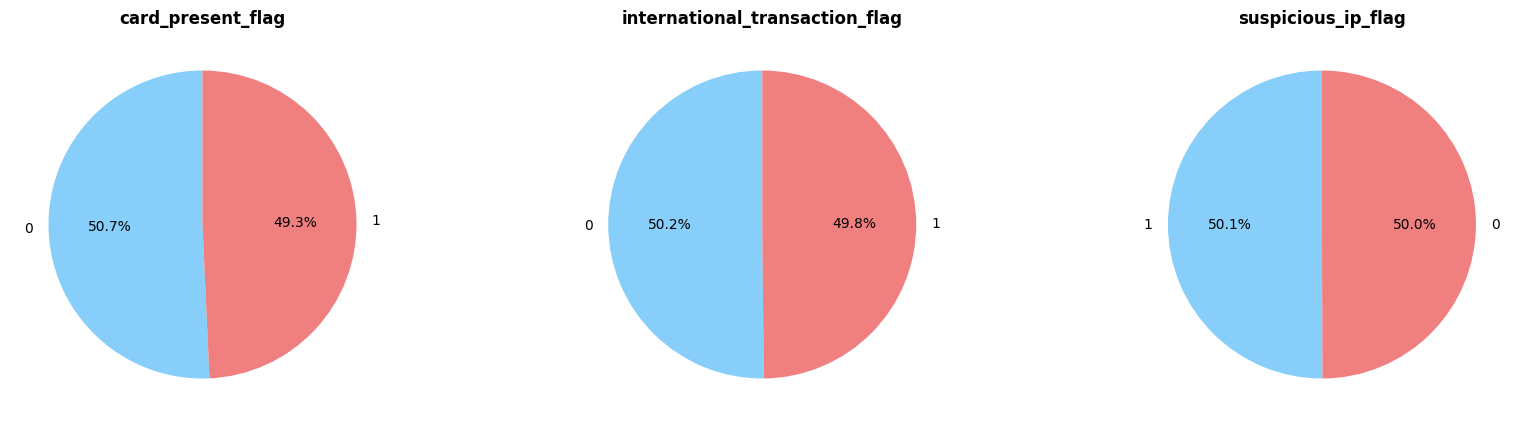


- Target Distribution -
fraud_flag
False    8749
True     1251
Name: count, dtype: int64


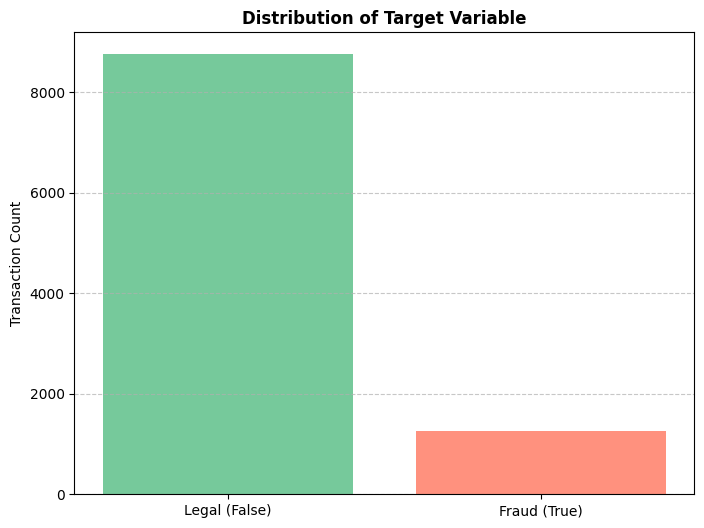

In [4]:
print("== EXPLORATORY DATA ANALYSIS ==")
print(data.head())

print("\n- Dataset Shape -")
print(data.shape)
print("\n- Dataset Information -")
print(data.info())
print("\n- Missing Values -")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])
print(f"{missing_values.sum()} missing values")
print("\n- Numeric Feature Distributions -")
for col in features["numeric"]:
    print(f"{col}: min={data[col].min()}, max={data[col].max()}, mean={data[col].mean():.2f}, median={data[col].median():.2f}")
visualize_numeric_feature_distributions(data, features["numeric"])
print("\n- Categorical Feature Distributions -")
for col in features["categorical"]:
    print(f"{col}: {data[col].value_counts().to_dict()}")
visualize_categorical_feature_distributions(data, features["categorical"])
print("\n- Binary Feature Distributions -")
for col in features["binary"]:
    print(f"{col}: {data[col].value_counts().to_dict()}")
visualize_binary_feature_distributions(data, features["binary"])
print("\n- Target Distribution -")
class_counts = data['fraud_flag'].value_counts()
print(class_counts)
visualize_target_distribution(data)

### DRZEWO DECYZYJNE


=== Decision Tree Model Performance ===
Accuracy: 0.9185

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1751
           1       0.68      0.65      0.67       249

    accuracy                           0.92      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.92      0.92      0.92      2000



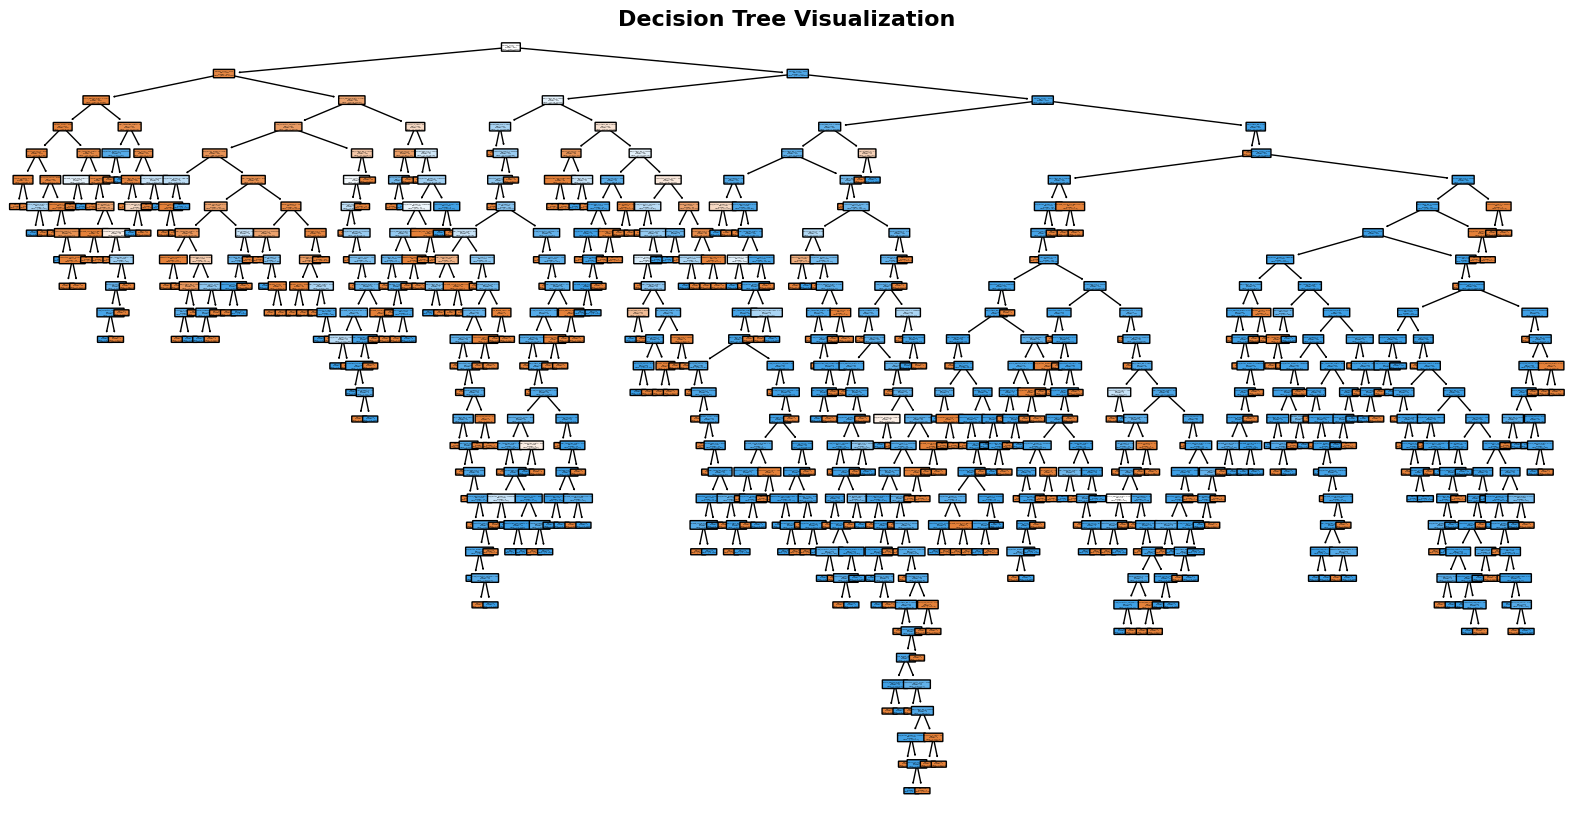

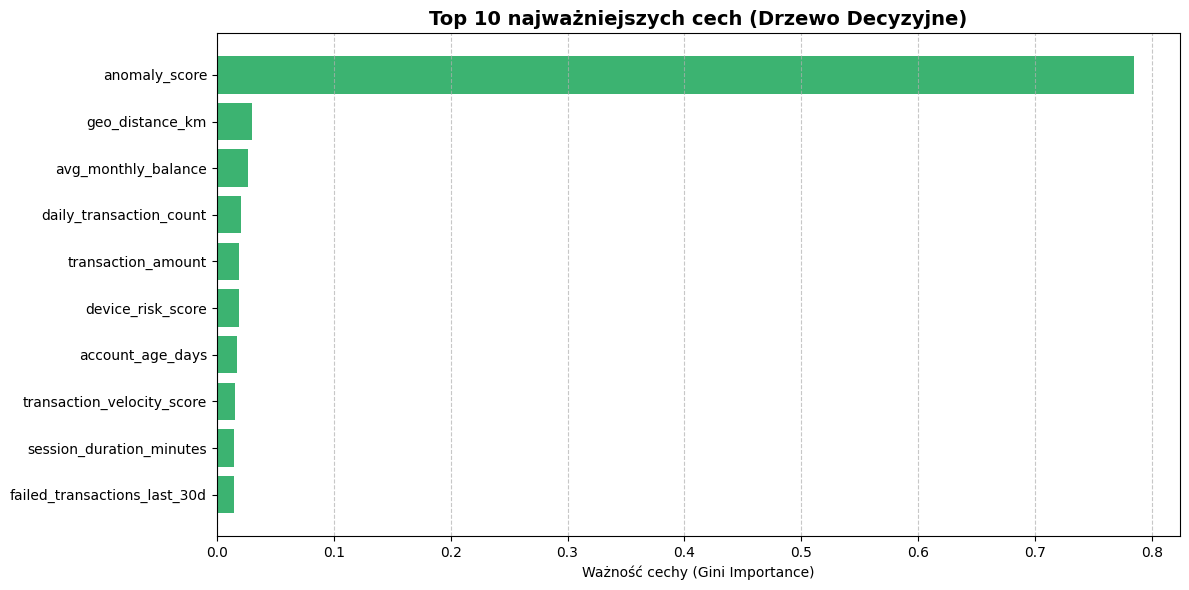

In [5]:
data = data_encoded

X = data.drop('fraud_flag', axis=1)
y = data['fraud_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = tree.DecisionTreeClassifier(class_weight='balanced', random_state=42) # max_depth żeby zmniejszyć drzewo
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

# Metryki
print("\n=== Decision Tree Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Wizualizacja drzewa
plt.figure(figsize=(20, 10))
tree.plot_tree(dt, filled=True, feature_names=X.columns, class_names=['Legal', 'Fraud'], rounded=True)
plt.title("Decision Tree Visualization", fontsize=16, fontweight='bold')
plt.show()

# lowest importance features
importances = dt.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Cecha': feature_names,
    'Ważność': importances
})

top_10_features = feature_importance_df.sort_values(by='Ważność', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_10_features['Cecha'], top_10_features['Ważność'], color='mediumseagreen')
plt.gca().invert_yaxis()
plt.title('Top 10 najważniejszych cech (Drzewo Decyzyjne)', fontsize=14, fontweight='bold')
plt.xlabel('Ważność cechy (Gini Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### XGBoost


=== XGBoost Model Performance ===
Accuracy: 0.9415

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1751
           1       0.75      0.80      0.77       249

    accuracy                           0.94      2000
   macro avg       0.86      0.88      0.87      2000
weighted avg       0.94      0.94      0.94      2000



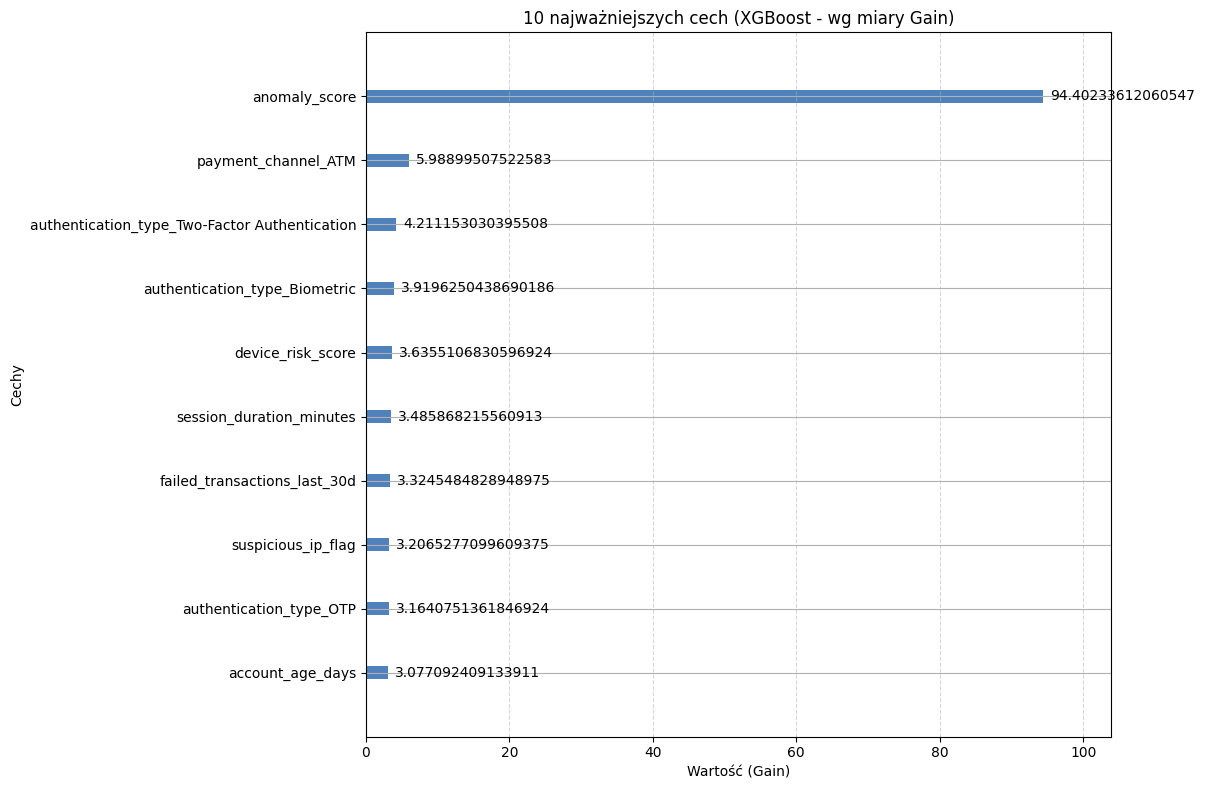

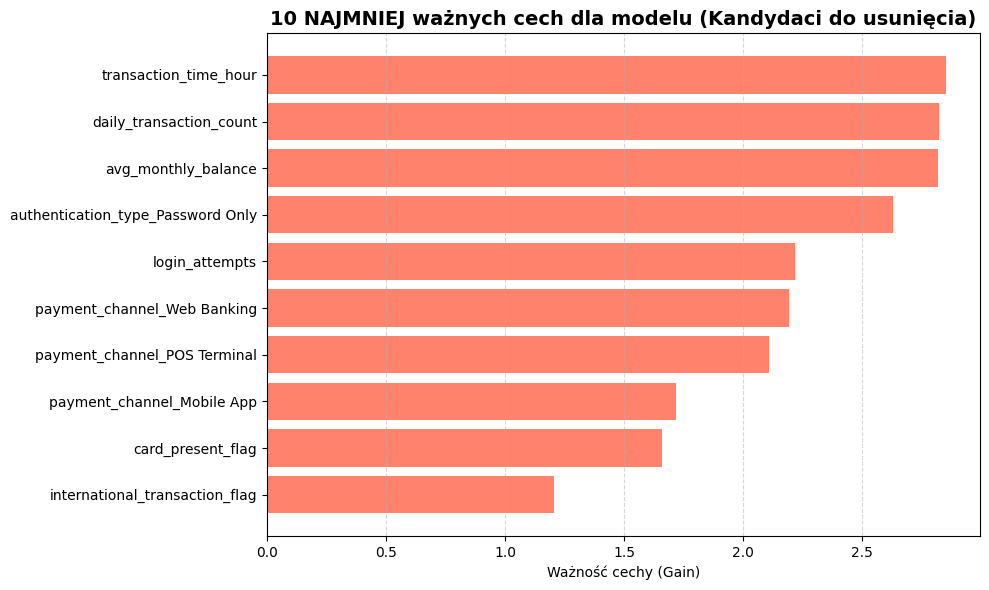

In [6]:
X = data.drop('fraud_flag', axis=1)
y = data['fraud_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

legal_count = sum(y == 0)
fraud_count = sum(y == 1)
weight = legal_count / fraud_count

xgb = XGBClassifier(scale_pos_weight=weight, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

# Metryki
print("\n=== XGBoost Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
fig, ax = plt.subplots(figsize=(12, 8))
plot_importance(xgb, ax=ax, max_num_features=10, importance_type='gain', 
                color='#4F81BD', title='10 najważniejszych cech (XGBoost - wg miary Gain)',
                xlabel='Wartość (Gain)', ylabel='Cechy')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


importance_dict = xgb.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Cecha': list(importance_dict.keys()),
    'Ważność': list(importance_dict.values())
})
bottom_10_features = importance_df.sort_values(by='Ważność', ascending=True).head(10)

plt.figure(figsize=(10, 6))
plt.barh(bottom_10_features['Cecha'], bottom_10_features['Ważność'], color='tomato', alpha=0.8)
plt.title('10 NAJMNIEJ ważnych cech dla modelu (Kandydaci do usunięcia)', fontsize=14, fontweight='bold')
plt.xlabel('Ważność cechy (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

==== RAPORT: PRZED OPTYMALIZACJĄ ====
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1751
           1       0.80      0.75      0.78       249

    accuracy                           0.95      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.94      0.95      0.95      2000


==== RAPORT: PO OPTYMALIZACJI ====
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1751
           1       0.61      0.93      0.74       249

    accuracy                           0.92      2000
   macro avg       0.80      0.92      0.85      2000
weighted avg       0.94      0.92      0.93      2000



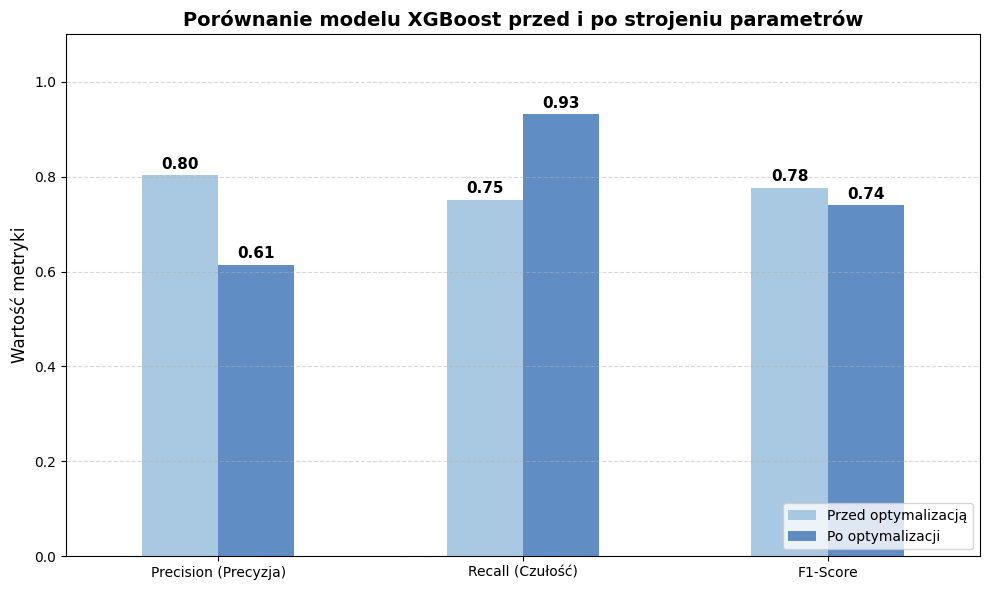

In [7]:
legal_count = sum(y_train == 0)
fraud_count = sum(y_train == 1)
weight = legal_count / fraud_count

# BASE MODEL
xgb_baseline = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train, y_train)
y_pred_base = xgb_baseline.predict(X_test)

print("==== RAPORT: PRZED OPTYMALIZACJĄ ====")
print(classification_report(y_test, y_pred_base))

precision_base, recall_base, f1_base, _ = precision_recall_fscore_support(y_test, y_pred_base, average=None)
metrics_base = [precision_base[1], recall_base[1], f1_base[1]]


# MODEL WITH OPTIMIZED HYPERPARAMETERS
xgb_optimized = XGBClassifier(
    scale_pos_weight=weight,    
    max_depth=3,                
    learning_rate=0.01,         
    n_estimators=500,     
    random_state=42,
    eval_metric='logloss'
)
xgb_optimized.fit(X_train, y_train)
y_pred_opt = xgb_optimized.predict(X_test)

print("\n==== RAPORT: PO OPTYMALIZACJI ====")
print(classification_report(y_test, y_pred_opt))

precision_opt, recall_opt, f1_opt, _ = precision_recall_fscore_support(y_test, y_pred_opt, average=None)
metrics_opt = [precision_opt[1], recall_opt[1], f1_opt[1]]


metrics_df = pd.DataFrame({
    'Przed optymalizacją': metrics_base,
    'Po optymalizacji': metrics_opt
}, index=['Precision (Precyzja)', 'Recall (Czułość)', 'F1-Score'])

ax = metrics_df.plot(kind='bar', figsize=(10, 6), color=['#A0C4DF', '#4F81BD'], alpha=0.9)
plt.title('Porównanie modelu XGBoost przed i po strojeniu parametrów', fontsize=14, fontweight='bold')
plt.ylabel('Wartość metryki', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11, fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

==== ETAP 1: MODEL BAZOWY (WSZYSTKIE CECHY) ====

==== ETAP 2: IDENTYFIKACJA I USUNIĘCIE 10 NAJSŁABSZYCH CECH ====
Usuwane cechy (najmniejszy wpływ na model):
['international_transaction_flag', 'card_present_flag', 'authentication_type_Two-Factor Authentication', 'payment_channel_Web Banking', 'transaction_time_hour', 'suspicious_ip_flag', 'avg_monthly_balance', 'login_attempts', 'session_duration_minutes', 'payment_channel_POS Terminal']

==== ETAP 3: MODEL ZREDUKOWANY (BEZ 10 CECH) ====
F1-Score na pełnych danych: 0.7759
F1-Score po usunięciu 10 cech: 0.7630

==== ETAP 4: WIZUALIZACJA PORÓWNAWCZA ====


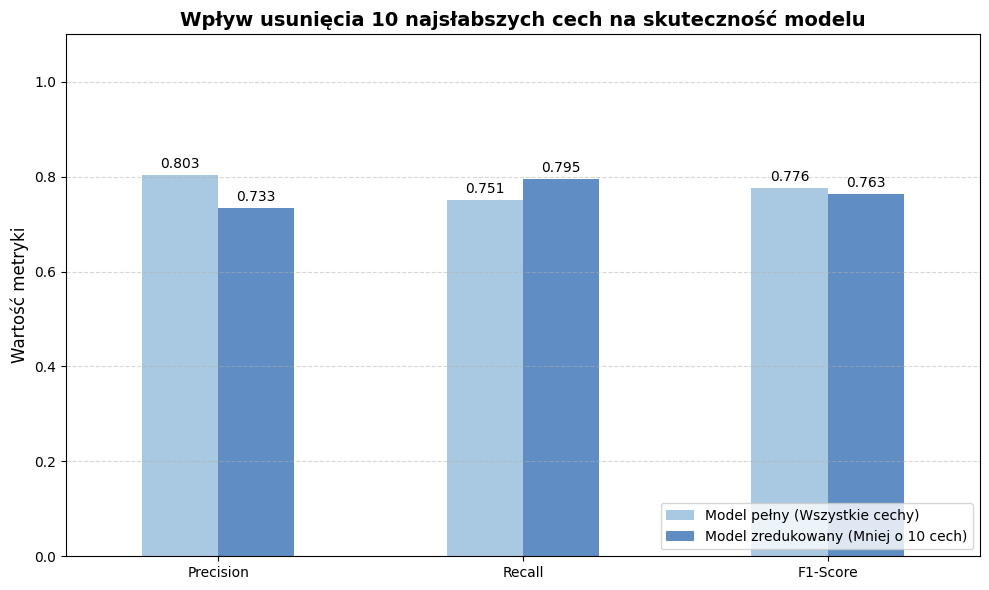

In [8]:
legal_count = sum(y_train == 0)
fraud_count = sum(y_train == 1)
weight = legal_count / fraud_count

print("==== ETAP 1: MODEL BAZOWY (WSZYSTKIE CECHY) ====")
xgb_full = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_full.fit(X_train, y_train)
y_pred_full = xgb_full.predict(X_test)

precision_f, recall_f, f1_f, _ = precision_recall_fscore_support(y_test, y_pred_full, average=None)
metrics_full = [precision_f[1], recall_f[1], f1_f[1]]

print("\n==== ETAP 2: IDENTYFIKACJA I USUNIĘCIE 10 NAJSŁABSZYCH CECH ====")
importances = xgb_full.feature_importances_
importance_df = pd.DataFrame({'Cecha': X_train.columns, 'Ważność': importances})

features_to_drop = importance_df.sort_values(by='Ważność', ascending=True).head(10)['Cecha'].tolist()
print(f"Usuwane cechy (najmniejszy wpływ na model):\n{features_to_drop}")
X_train_reduced = X_train.drop(columns=features_to_drop)
X_test_reduced = X_test.drop(columns=features_to_drop)


print("\n==== ETAP 3: MODEL ZREDUKOWANY (BEZ 10 CECH) ====")
xgb_reduced = XGBClassifier(scale_pos_weight=weight, random_state=42, eval_metric='logloss')
xgb_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = xgb_reduced.predict(X_test_reduced)

precision_r, recall_r, f1_r, _ = precision_recall_fscore_support(y_test, y_pred_reduced, average=None)
metrics_reduced = [precision_r[1], recall_r[1], f1_r[1]]
print(f"F1-Score na pełnych danych: {f1_f[1]:.4f}")
print(f"F1-Score po usunięciu 10 cech: {f1_r[1]:.4f}")

print("\n==== ETAP 4: WIZUALIZACJA PORÓWNAWCZA ====")
metrics_df = pd.DataFrame({
    'Model pełny (Wszystkie cechy)': metrics_full,
    'Model zredukowany (Mniej o 10 cech)': metrics_reduced
}, index=['Precision', 'Recall', 'F1-Score'])

ax = metrics_df.plot(kind='bar', figsize=(10, 6), color=['#A0C4DF', '#4F81BD'], alpha=0.9)
plt.title('Wpływ usunięcia 10 najsłabszych cech na skuteczność modelu', fontsize=14, fontweight='bold')
plt.ylabel('Wartość metryki', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Dodanie dokładnych wartości liczbowych nad słupkami
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

==== ETAP 1: ZOPTYMALIZOWANY MODEL (WSZYSTKIE CECHY) ====

==== ETAP 2: IDENTYFIKACJA I USUNIĘCIE 10 NAJSŁABSZYCH CECH ====
Usuwane cechy (najmniejszy wpływ w optymalnym modelu):\n['suspicious_ip_flag', 'card_present_flag', 'international_transaction_flag', 'authentication_type_Two-Factor Authentication', 'authentication_type_OTP', 'payment_channel_Web Banking', 'payment_channel_POS Terminal', 'payment_channel_Mobile App', 'authentication_type_Password Only', 'transaction_amount']

==== ETAP 3: ZOPTYMALIZOWANY MODEL (ZREDUKOWANE DANE) ====
F1-Score na pełnych danych: 0.7400
F1-Score po usunięciu 10 cech: 0.7468

==== ETAP 4: WIZUALIZACJA PORÓWNAWCZA ====


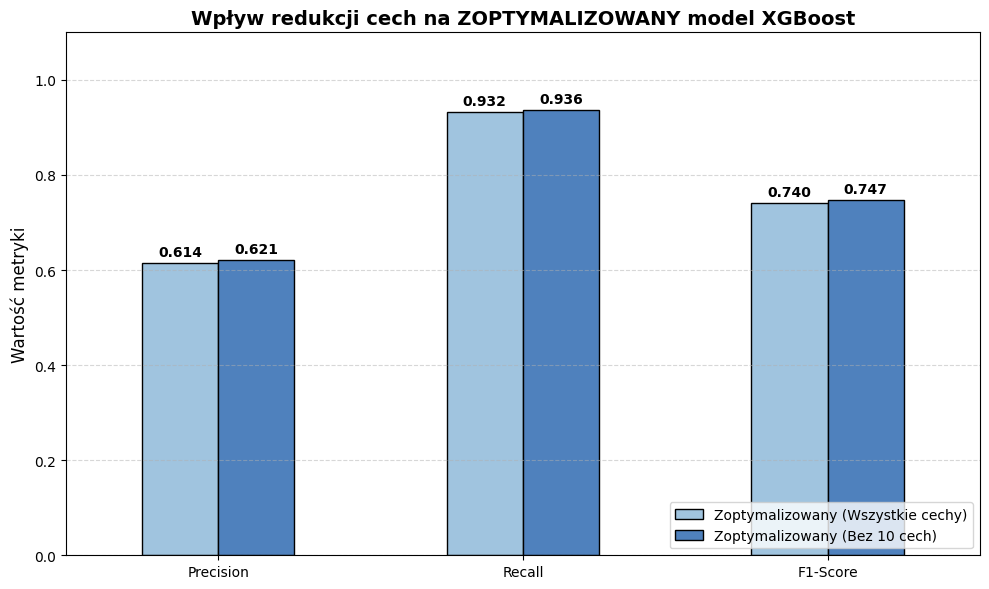

In [9]:
legal_count = sum(y_train == 0)
fraud_count = sum(y_train == 1)
weight = legal_count / fraud_count

best_params = {
    'scale_pos_weight': weight,
    'max_depth': 3,
    'learning_rate': 0.01,
    'n_estimators': 500,
    'random_state': 42,
    'eval_metric': 'logloss'
}

print("==== ETAP 1: ZOPTYMALIZOWANY MODEL (WSZYSTKIE CECHY) ====")
xgb_opt_full = XGBClassifier(**best_params)
xgb_opt_full.fit(X_train, y_train)
y_pred_opt_full = xgb_opt_full.predict(X_test)

precision_of, recall_of, f1_of, _ = precision_recall_fscore_support(y_test, y_pred_opt_full, average=None)
metrics_opt_full = [precision_of[1], recall_of[1], f1_of[1]]


print("\n==== ETAP 2: IDENTYFIKACJA I USUNIĘCIE 10 NAJSŁABSZYCH CECH ====")
importances_opt = xgb_opt_full.feature_importances_
importance_opt_df = pd.DataFrame({'Cecha': X_train.columns, 'Ważność': importances_opt})

features_to_drop_opt = importance_opt_df.sort_values(by='Ważność', ascending=True).head(10)['Cecha'].tolist()
print(f"Usuwane cechy (najmniejszy wpływ w optymalnym modelu):\\n{features_to_drop_opt}")

X_train_reduced_opt = X_train.drop(columns=features_to_drop_opt)
X_test_reduced_opt = X_test.drop(columns=features_to_drop_opt)


print("\n==== ETAP 3: ZOPTYMALIZOWANY MODEL (ZREDUKOWANE DANE) ====")
xgb_opt_reduced = XGBClassifier(**best_params)
xgb_opt_reduced.fit(X_train_reduced_opt, y_train)
y_pred_opt_reduced = xgb_opt_reduced.predict(X_test_reduced_opt)

precision_or, recall_or, f1_or, _ = precision_recall_fscore_support(y_test, y_pred_opt_reduced, average=None)
metrics_opt_reduced = [precision_or[1], recall_or[1], f1_or[1]]

print(f"F1-Score na pełnych danych: {f1_of[1]:.4f}")
print(f"F1-Score po usunięciu 10 cech: {f1_or[1]:.4f}")


print("\n==== ETAP 4: WIZUALIZACJA PORÓWNAWCZA ====")
metrics_df_opt = pd.DataFrame({
    'Zoptymalizowany (Wszystkie cechy)': metrics_opt_full,
    'Zoptymalizowany (Bez 10 cech)': metrics_opt_reduced
}, index=['Precision', 'Recall', 'F1-Score'])

ax = metrics_df_opt.plot(kind='bar', figsize=(10, 6), color=['#A0C4DF', '#4F81BD'], edgecolor='black')
plt.title('Wpływ redukcji cech na ZOPTYMALIZOWANY model XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Wartość metryki', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Trwa trenowanie modeli do ostatecznego porównania...
Zakończono! Generowanie wykresu...



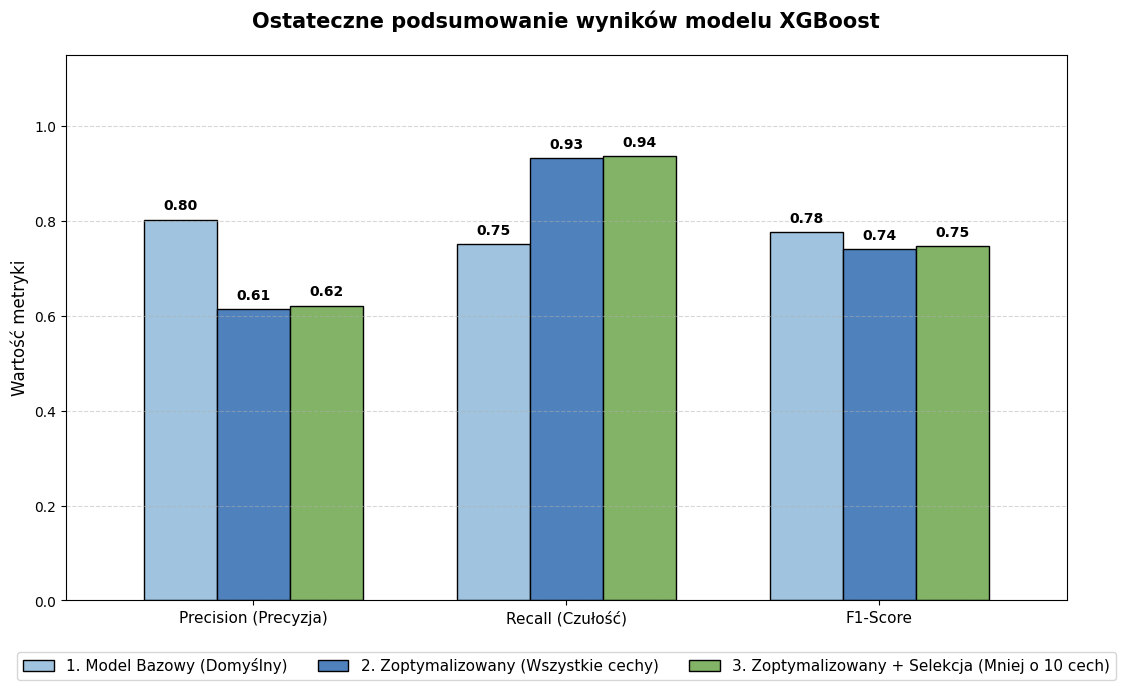

In [10]:

legal_count = sum(y_train == 0)
fraud_count = sum(y_train == 1)
weight = legal_count / fraud_count

best_params = {
    'scale_pos_weight': weight,
    'max_depth': 3,
    'learning_rate': 0.01,
    'n_estimators': 500,
    'random_state': 42,
    'eval_metric': 'logloss'
}

print("Trwa trenowanie modeli do ostatecznego porównania...")

# =========================================================
# 1. MODEL BAZOWY (Domyślny, brak balansu klas)
# =========================================================
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_test)

p_base, r_base, f1_base, _ = precision_recall_fscore_support(y_test, y_pred_base, average=None)
metrics_base = [p_base[1], r_base[1], f1_base[1]]

# =========================================================
# 2. MODEL ZOPTYMALIZOWANY (Wszystkie cechy, zbalansowany)
# =========================================================
xgb_opt = XGBClassifier(**best_params)
xgb_opt.fit(X_train, y_train)
y_pred_opt = xgb_opt.predict(X_test)

p_opt, r_opt, f1_opt, _ = precision_recall_fscore_support(y_test, y_pred_opt, average=None)
metrics_opt = [p_opt[1], r_opt[1], f1_opt[1]]

# =========================================================
# 3. MODEL ZOPTYMALIZOWANY + SELEKCJA CECH (Bez 10 najsłabszych)
# =========================================================
importances = xgb_opt.feature_importances_
imp_df = pd.DataFrame({'Cecha': X_train.columns, 'Ważność': importances})
features_to_drop = imp_df.sort_values(by='Ważność', ascending=True).head(10)['Cecha'].tolist()

X_train_red = X_train.drop(columns=features_to_drop)
X_test_red = X_test.drop(columns=features_to_drop)

xgb_red = XGBClassifier(**best_params)
xgb_red.fit(X_train_red, y_train)
y_pred_red = xgb_red.predict(X_test_red)

p_red, r_red, f1_red, _ = precision_recall_fscore_support(y_test, y_pred_red, average=None)
metrics_red = [p_red[1], r_red[1], f1_red[1]]

print("Zakończono! Generowanie wykresu...\n")


# =========================================================
# WIZUALIZACJA: OSTATECZNE PORÓWNANIE
# =========================================================
comparison_df = pd.DataFrame({
    '1. Model Bazowy (Domyślny)': metrics_base,
    '2. Zoptymalizowany (Wszystkie cechy)': metrics_opt,
    '3. Zoptymalizowany + Selekcja (Mniej o 10 cech)': metrics_red
}, index=['Precision (Precyzja)', 'Recall (Czułość)', 'F1-Score'])

colors = ['#A0C4DF', '#4F81BD', '#82B366'] # Czerwony (źle), Niebieski (lepiej), Zielony (najlepiej/najlżej)
ax = comparison_df.plot(kind='bar', figsize=(12, 7), color=colors, edgecolor='black', width=0.7)

plt.title('Ostateczne podsumowanie wyników modelu XGBoost', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Wartość metryki', fontsize=12)
plt.ylim(0, 1.15)
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(f"{val:.2f}", (p.get_x() + p.get_width() / 2., val),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=11)
plt.tight_layout()
plt.show()

WNIOSKI KOŃCOWE: dobór parametrów pozwolił na osiągnięcie znacznie większej czułości, jednak obniżył w tym samym czasie precyzje. W systemach wykrywania oszustw, stopień detekcji jest istotniejszy niż to ile z podniesionych alarmów będzie fałszywe, a przy dalszej optymalizacji możliwe byłoby zniwelowanie strat na precyzji. Dodatkowo, zignorowanie znacznej ilości cech nie wpłynęło negatywnie na model, a przy dobrym doborze parametrów nawet minimalnie poprawiło skuteczność. Pokazuje to że można osiągnąć taką samą lub wyższą skuteczność przy odciążeniu systemu z mało istotnych danych.